In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parents[3]))  # .../SystemSimulation
from demos.ControlledPendulum.src.master_pendulum.components import (
    OpenSimPendulum,
    FEMPendulum,
    PendulumODE, 
    constant_torque,
    ramp_torque,
    zero_torque,
)
from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config
from thesis.plot_setup import set_professional_style
plt = set_professional_style()

In [2]:
mesh_params = config.MeshParameters()

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 40 # Nm

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3    # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 2700  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.001
sim_params.t_end = 1
sim_params.with_contact = False
sim_params.use_gravity = False

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'mat_params': mat_params,
    'contact_params': contact_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
    'mesh_params': mesh_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")

pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

t = 0.0
dt = pendulum.fem.sim_params.tau
t_end = pendulum.fem.sim_params.t_end

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
MasterPendulum: Detected direct_feedthrough={'q': set(), 'omega': set(),

In [3]:
pendulum.use_gravity

False

In [4]:
model = pendulum.fem
t_end = sim_params.t_end
dt = sim_params.tau
t = 0.0

torque_amp = init_params.drive_torque
torque_func: callable = ramp_torque(t_end, torque_amp)
# torque_func: callable = constant_torque(torque_amp)
# torque_func: callable = zero_torque

torque_type = ""
if isinstance(torque_func, type(ramp_torque)):
    torque_type = "ramp"
elif isinstance(torque_func, type(constant_torque)):
    torque_type = "constant"
elif isinstance(torque_func, type(zero_torque)):
    torque_type = "zero"

# Analytical Solution using ODE Pendulum
pendulum_ode = PendulumODE(
    mass=model.mass,
    length=model._equivalent_length,
    inertia=model.inertia,
    g=9.81 if model.sim_params.use_gravity else 0.0,
)


t_an_vals, q_an_vals, omega_an_vals, alpha_an_vals = pendulum_ode.solve(
    t_span=(0.0, t_end),
    y0=[np.deg2rad(init_params.angular_position_deg), 0.0],
    torque_func=torque_func,
    dt=dt / 100,
)

In [5]:
pendulum.setup_monitoring()
pendulum.display_monitoring()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [6]:
pendulum.fmu.get_parameters()

{'L': <Quantity(0.605502848, 'meter')>,
 'g': <Quantity(0.0, 'meter / second ** 2')>,
 'inertia': <Quantity(18.9003518, 'kilogram * meter ** 2')>,
 'm': <Quantity(41.7036956, 'kilogram')>,
 'omega0': <Quantity(0.0, 'radian / second')>,
 'q0': <Quantity(0.0, 'radian')>}

In [7]:
while t < t_end:
    # 1) Compute input torque
    torque = torque_func(t)

    # 2) Perform simulation step
    pendulum.set_inputs({"torque": torque}, t=t)

    # 3) Integrate one time step
    pendulum.do_step(t, dt)

    # 4) Advance time
    t += dt

[MasterPendulum] Switching: FMU to OpenSim @ t=0.0500s
[MasterPendulum] Switching: OpenSim to FEM @ t=0.1000s
[MasterPendulum] Switching: FEM to FMU @ t=0.1670s
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one

In [13]:
t_vals = {mode: [] for mode in pendulum.models.keys()}
torque_vals = {mode: [] for mode in pendulum.models.keys()}
alpha_vals = {mode: [] for mode in pendulum.models.keys()}
omega_vals = {mode: [] for mode in pendulum.models.keys()}
q_vals = {mode: [] for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    t_vals[mode], res_dict = pendulum.models[mode].get_history_arrays()
    alpha_vals[mode] = res_dict["alpha"]
    omega_vals[mode] = res_dict["omega"]
    q_vals[mode] = res_dict["q"]

In [14]:
rel_errors = {mode: {"q": [], "omega": [], "alpha": []} for mode in pendulum.models.keys()}
for mode in pendulum.models.keys():
    # Interpolate analytical solution to the time points of the model
    t_num = t_vals[mode]
    q_an_interp = np.interp(t_num, t_an_vals, q_an_vals)
    omega_an_interp = np.interp(t_num, t_an_vals, omega_an_vals)
    alpha_an_interp = np.interp(t_num, t_an_vals, alpha_an_vals)

    # Calculate relative errors
    eps = 1e-12
    q_num = q_vals[mode]
    omega_num = omega_vals[mode]
    alpha_num = alpha_vals[mode]
    rel_errors[mode]["q"] = np.abs(q_num - q_an_interp) / np.max(np.abs(q_an_interp))
    rel_errors[mode]["omega"] = np.abs(omega_num - omega_an_interp) / np.max(
        np.abs(omega_an_interp)
    )
    rel_errors[mode]["alpha"] = np.abs(alpha_num - alpha_an_interp) / np.max(
        np.abs(alpha_an_interp)
    )

In [15]:
marker_size = 3
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "FEM",
}
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "OpenSim",
}  # Green
eqb_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "EQB",
}  # Purple
fontdict = {"fontsize": 11, "fontweight": "bold"}

fig_size = (9, 9)
y_suptitle = 1.04
y_subtitle = 1
y_legend = 0.99
top_adjust = 0.9

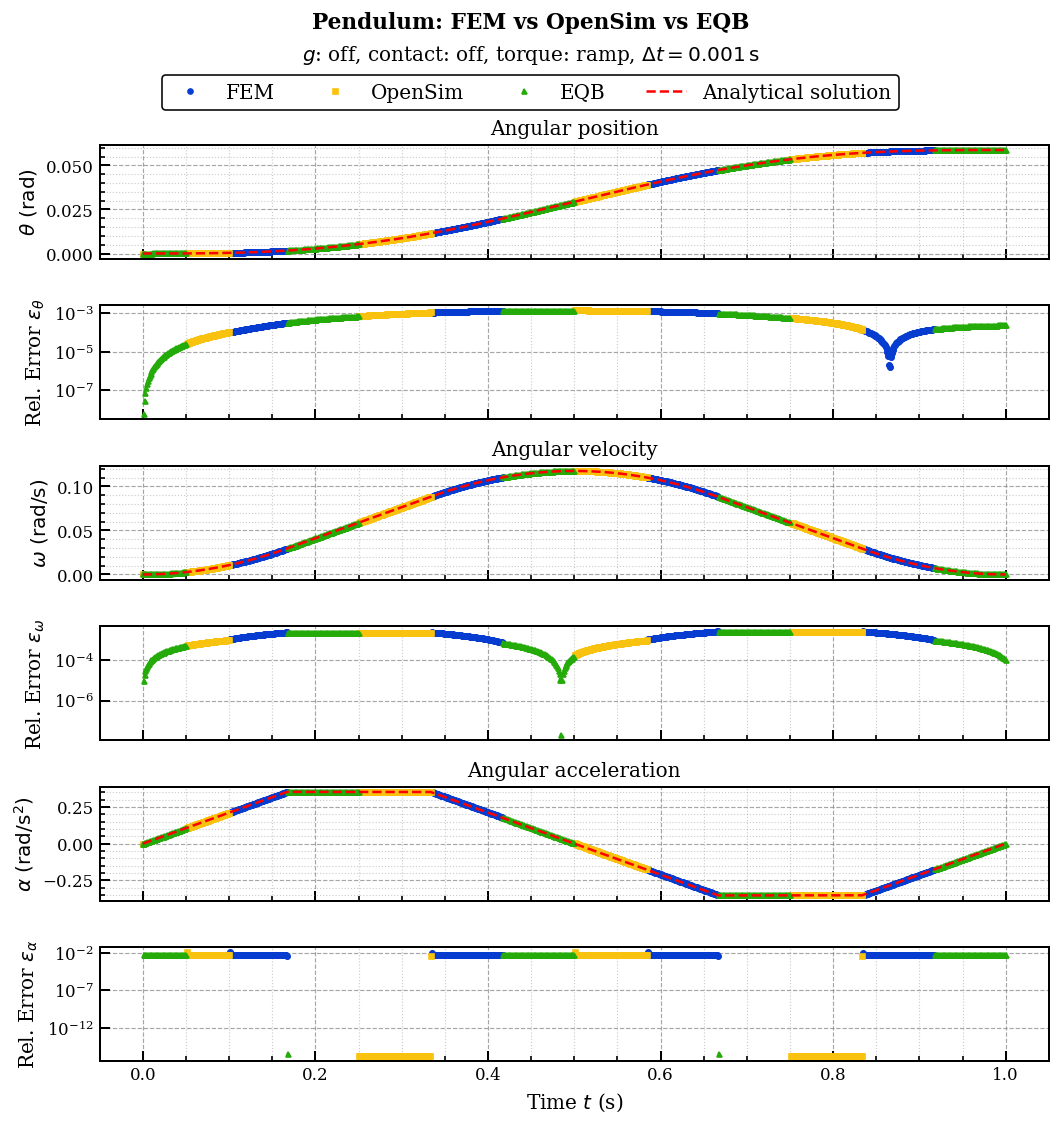

In [16]:
fig, axs = plt.subplots(6, 1, figsize=fig_size, sharex=True)

main_title = "Pendulum: FEM vs OpenSim vs EQB"
fig.suptitle(main_title, fontsize=13, fontweight="bold", y=y_suptitle)
param_str = (
    rf"$g$: {'on' if sim_params.use_gravity else 'off'}, "
    rf"contact: {'on' if sim_params.with_contact else 'off'}, "
    rf"torque: {torque_type}, "
    rf"$\Delta t = {dt}\,\mathrm{{s}}$"
)
fig.text(0.5, y_subtitle, param_str, ha="center", va="center")

axs[0].set_title(r"Angular position")
(line_fem_q,) = axs[0].plot(t_vals["FEM"], q_vals["FEM"], **fem_style)
(line_osim_q,) = axs[0].plot(t_vals["OpenSim"], q_vals["OpenSim"], **opensim_style)
(line_eqb_q,) = axs[0].plot(t_vals["FMU"], q_vals["FMU"], **eqb_style)
(line_analytical_q,) = axs[0].plot(
    t_an_vals, q_an_vals, label="Analytical solution", color="red", linestyle="--", linewidth=1.5
)
axs[0].set_ylabel(r"$\theta\ \mathrm{(rad)}$")

axs[1].semilogy(t_vals["FEM"], rel_errors["FEM"]["q"], **fem_style)
axs[1].semilogy(t_vals["OpenSim"], rel_errors["OpenSim"]["q"], **opensim_style)
axs[1].semilogy(t_vals["FMU"], rel_errors["FMU"]["q"], **eqb_style)
axs[1].set_ylabel(r"Rel. Error $\epsilon_\theta$")

axs[2].set_title(r"Angular velocity")
axs[2].plot(t_vals["FEM"], omega_vals["FEM"], **fem_style)
axs[2].plot(t_vals["OpenSim"], omega_vals["OpenSim"], **opensim_style)
axs[2].plot(t_vals["FMU"], omega_vals["FMU"], **eqb_style)
axs[2].plot(t_an_vals, omega_an_vals, color="red", linestyle="--", linewidth=1.5)
axs[2].set_ylabel(r"$\omega\ \mathrm{(rad/s)}$")

axs[3].semilogy(t_vals["FEM"], rel_errors["FEM"]["omega"], **fem_style)
axs[3].semilogy(t_vals["OpenSim"], rel_errors["OpenSim"]["omega"], **opensim_style)
axs[3].semilogy(t_vals["FMU"], rel_errors["FMU"]["omega"], **eqb_style)
axs[3].set_ylabel(r"Rel. Error $\epsilon_\omega$")

axs[4].set_title(r"Angular acceleration")
axs[4].plot(t_vals["FEM"], alpha_vals["FEM"], **fem_style)
axs[4].plot(t_vals["OpenSim"], alpha_vals["OpenSim"], **opensim_style)
axs[4].plot(t_vals["FMU"], alpha_vals["FMU"], **eqb_style)
axs[4].plot(t_an_vals, alpha_an_vals, color="red", linestyle="--", linewidth=1.5)
axs[4].set_ylabel(r"$\alpha\ \mathrm{(rad/s^2)}$")

axs[5].semilogy(t_vals["FEM"], rel_errors["FEM"]["alpha"], **fem_style)
axs[5].semilogy(t_vals["OpenSim"], rel_errors["OpenSim"]["alpha"], **opensim_style)
axs[5].semilogy(t_vals["FMU"], rel_errors["FMU"]["alpha"], **eqb_style)
axs[5].set_ylabel(r"Rel. Error $\epsilon_\alpha$")

axs[5].set_xlabel(r"Time $t$ (s)")

handles = [line_fem_q, line_osim_q, line_eqb_q, line_analytical_q]
labels = [h.get_label() for h in handles]

fig.legend(
    handles, labels, loc="upper center", bbox_to_anchor=(0.5, y_legend), ncol=4, frameon=True
)

for ax in axs:
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle="--", alpha=0.7)
    ax.grid(True, which="minor", linestyle=":", alpha=0.4)

plt.subplots_adjust(top=top_adjust)
plt.tight_layout()
#plt.savefig("../figures/StateSynchronization_driven.svg")
plt.show()

In [12]:
import pandas as pd
import tabulate

# Create DataFrame for better handling
sync_data = []

for event in pendulum.sync_events:
    # Extract values
    time = event["time"]
    from_mode = event["from_mode"]
    to_mode = event["to_mode"]

    ret = event["retrieved"]
    new = event["now"]

    # Helper to extract magnitude
    def get_val(x):
        if hasattr(x, "magnitude"):
            return x.magnitude
        return float(x) if hasattr(x, "__float__") else x

    sync_data.append(
        {
            "Time (s)": f"{time:.4f}",
            "Transition": f"{from_mode} → {to_mode}",
            "θ_ret (°)": f"{np.rad2deg(get_val(ret['q']['value'])):.2f}",
            "ω_ret": f"{get_val(ret['omega']['value']):.3f}",
            "α_ret": f"{get_val(ret['alpha']['value']):.1f}",
            "τ_ret": f"{get_val(ret['torque']['value']):.2f}",
            "θ_new (°)": f"{np.rad2deg(get_val(new['q']['value'])):.2f}",
            "ω_new": f"{get_val(new['omega']['value']):.3f}",
            "α_new": f"{get_val(new['alpha']['value']):.1f}",
            "τ_new": f"{get_val(new['torque']['value']):.2f}",
        }
    )

df = pd.DataFrame(sync_data)

print("\n" + "=" * 140)
print(" " * 50 + "MODE SYNCHRONIZATION EVENTS")
print("=" * 140)
print(tabulate.tabulate(df, headers="keys", tablefmt="grid", showindex=False))
print("=" * 140)
print(f"Total mode switches: {len(sync_data)}")
print("=" * 140 + "\n")

KeyError: 'q'